# 基于 ML 传感器构建交通图（含地图可视化）

- 数据源：sensors_common_2025.csv（全年存在的传感器）
- 只保留 ML（主线）传感器
- 按 Fwy + Dir 分组，Abs_PM 排序，相邻节点连边
- 边权重：高斯核函数（基于距离）
- 有向图：边方向与行驶方向一致
- **新增**：交互式地图可视化，支持检查图结构

## 1. 环境配置

In [24]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os

# 地图可视化
import folium
from folium import plugins

OUTPUT_DIR = "../output"
META_DIR = "../d03_meta_processed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("库加载完成！")

库加载完成！


## 2. 加载数据并筛选 ML 传感器

In [25]:
# 加载全年存在的传感器
df = pd.read_csv(os.path.join(META_DIR, 'sensors_common_2025.csv'), dtype={'ID': str, 'Fwy': str})
print(f"全部传感器数: {len(df)}")

# 筛选 ML（主线）传感器
ml_df = df[df['Type'] == 'ML'].copy()
print(f"ML 传感器数: {len(ml_df)}")

# 查看数据
display(ml_df[['ID', 'Fwy', 'Dir', 'Abs_PM', 'Latitude', 'Longitude', 'Lanes', 'Name']].head(10))

全部传感器数: 1830
ML 传感器数: 854


,ID,Fwy,Dir,Abs_PM,Latitude,Longitude,Lanes,Name
0,308511,50,E,60.162,38.761062,-120.569835,2,Sly Park Rd
1,308512,50,W,60.166,38.761182,-120.569866,2,Sly Park Rd
7,311903,50,E,3.789,38.566906,-121.505888,3,50EB at 6TH Street
10,311974,50,E,4.376,38.564153,-121.495585,5,15th St
12,312010,50,W,4.501,38.563816,-121.493316,5,15th St
15,312098,50,E,5.496,38.559020,-121.476106,4,28th St
17,312103,50,W,6.221,38.560995,-121.462999,4,Stockton Blvd
21,312132,5,S,506.189,38.409782,-121.484120,2,5SB at Elk Grove Blvd
22,312133,5,N,507.476,38.428229,-121.487572,3,5NB at Laguna Blvd
23,312134,5,N,506.373,38.412421,-121.484289,2,5NB at Elk Grove Blvd


In [26]:
# 统计
print("按高速公路统计:")
print(ml_df.groupby(['Fwy', 'Dir']).size().sort_values(ascending=False).head(15))

按高速公路统计:
Fwy  Dir
50   E      107
     W      103
80   E       98
     W       95
99   S       82
     N       75
5    N       54
     S       54
51   N       22
     S       19
65   S       17
     N       15
20   W       11
     E        9
70   E        8
dtype: int64


## 3. 定义高斯核函数

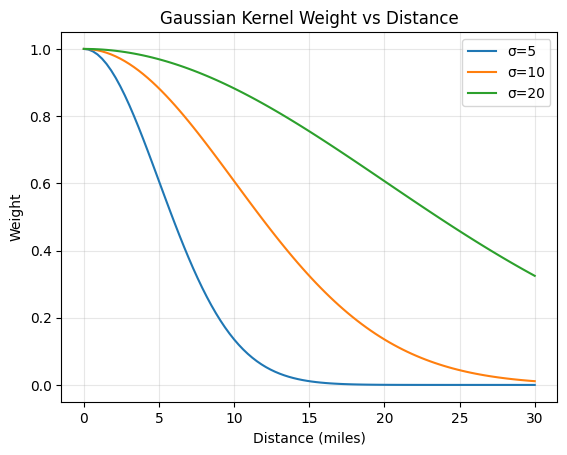

In [27]:
def gaussian_kernel(distance, sigma=10.0):
    """
    高斯核函数计算边权重
    
    w = exp(-d^2 / (2 * sigma^2))
    """
    return np.exp(-distance**2 / (2 * sigma**2))


# 可视化
distances = np.linspace(0, 30, 100)
for sigma in [5, 10, 20]:
    weights = gaussian_kernel(distances, sigma)
    plt.plot(distances, weights, label=f'σ={sigma}')

plt.xlabel('Distance (miles)')
plt.ylabel('Weight')
plt.title('Gaussian Kernel Weight vs Distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. 构建有向交通图

In [28]:
def build_traffic_graph(ml_df, sigma=10.0):
    """
    构建有向交通图
    
    - 节点：ML 传感器
    - 边：同一 Fwy+Dir 上的相邻传感器
    - 方向：与行驶方向一致
    - 权重：高斯核（基于距离）
    """
    G = nx.DiGraph()
    
    # 添加节点
    for _, row in ml_df.iterrows():
        G.add_node(row['ID'],
                   fwy=row['Fwy'],
                   dir=row['Dir'],
                   abs_pm=row['Abs_PM'],
                   lat=row['Latitude'],
                   lon=row['Longitude'],
                   lanes=row['Lanes'],
                   name=row['Name'])
    
    # 按 Fwy + Dir 分组构建边
    edge_count = 0
    for (fwy, direction), group in ml_df.groupby(['Fwy', 'Dir']):
        # 按 Abs_PM 排序
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        
        # 相邻节点连边
        for i in range(len(sorted_group) - 1):
            node1 = sorted_group.iloc[i]
            node2 = sorted_group.iloc[i + 1]
            
            # 计算距离和权重
            distance = abs(node2['Abs_PM'] - node1['Abs_PM'])
            weight = gaussian_kernel(distance, sigma)
            
            # 确定边方向（与行驶方向一致）
            if direction in ['N', 'E']:  # 北/东：PM递增方向
                src, dst = node1['ID'], node2['ID']
            else:  # 南/西：PM递减方向
                src, dst = node2['ID'], node1['ID']
            
            G.add_edge(src, dst, 
                       distance=distance, 
                       weight=weight,
                       fwy=fwy,
                       dir=direction)
            edge_count += 1
    
    print(f"节点数: {G.number_of_nodes()}")
    print(f"边数: {G.number_of_edges()}")
    
    return G


# 构建图
SIGMA = 10.0  # 高斯核带宽参数
G = build_traffic_graph(ml_df, sigma=SIGMA)
print(f"\n使用 sigma = {SIGMA}")

节点数: 854
边数: 814

使用 sigma = 10.0


## 5. 图统计信息

In [29]:
# 基本统计
print("=" * 50)
print("图统计信息")
print("=" * 50)
print(f"节点数: {G.number_of_nodes()}")
print(f"边数: {G.number_of_edges()}")
print(f"是否有向图: {G.is_directed()}")

# 连通分量
weakly_connected = list(nx.weakly_connected_components(G))
print(f"弱连通分量数: {len(weakly_connected)}")
print(f"最大分量节点数: {max(len(c) for c in weakly_connected)}")

# 边权重统计
distances = [G.edges[e]['distance'] for e in G.edges]
weights = [G.edges[e]['weight'] for e in G.edges]

print(f"\n边距离统计 (miles):")
print(f"  最小: {min(distances):.3f}")
print(f"  最大: {max(distances):.3f}")
print(f"  平均: {np.mean(distances):.3f}")

print(f"\n边权重统计:")
print(f"  最小: {min(weights):.4f}")
print(f"  最大: {max(weights):.4f}")
print(f"  平均: {np.mean(weights):.4f}")

图统计信息
节点数: 854
边数: 814
是否有向图: True
弱连通分量数: 40
最大分量节点数: 107

边距离统计 (miles):
  最小: 0.000
  最大: 36.372
  平均: 1.867

边权重统计:
  最小: 0.0013
  最大: 1.0000
  平均: 0.9518


## 6. 地图可视化（交互式）

**功能**：
- 每个节点显示详细信息（ID, Fwy, Dir, Abs_PM, Lanes, Name）
- 边用箭头表示方向
- 可按高速公路筛选
- 支持缩放和平移

In [30]:
def create_traffic_map(G, ml_df, filter_fwy=None, filter_dir=None, use_cluster=False):
    """
    创建交通图的交互式地图
    
    参数:
    - G: networkx 图
    - ml_df: 传感器元数据
    - filter_fwy: 筛选特定高速公路（如 '50', '80'）
    - filter_dir: 筛选特定方向（如 'N', 'S', 'E', 'W'）
    - use_cluster: 是否使用聚类标记
    """
    from folium.plugins import MarkerCluster
    
    # 计算地图中心（排除 NaN）
    valid_coords = ml_df.dropna(subset=['Latitude', 'Longitude'])
    valid_coords = valid_coords[(valid_coords['Latitude'] != 0) & (valid_coords['Longitude'] != 0)]
    center_lat = valid_coords['Latitude'].mean()
    center_lon = valid_coords['Longitude'].mean()
    
    # 创建地图
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=9,
        tiles='OpenStreetMap'
    )
    
    # 颜色映射（按高速公路）
    fwy_colors = {
        '5': 'red',
        '50': 'blue',
        '80': 'green',
        '99': 'purple',
        '51': 'orange',
        '65': 'darkred',
        '20': 'darkblue',
        '70': 'darkgreen'
    }
    
    # 筛选节点（排除坐标为 NaN 的节点）
    nodes_to_show = []
    skipped_count = 0
    for node_id in G.nodes():
        node_data = G.nodes[node_id]
        if filter_fwy and node_data['fwy'] != filter_fwy:
            continue
        if filter_dir and node_data['dir'] != filter_dir:
            continue
        # 检查坐标是否有效
        if pd.isna(node_data['lat']) or pd.isna(node_data['lon']):
            skipped_count += 1
            continue
        if node_data['lat'] == 0 or node_data['lon'] == 0:
            skipped_count += 1
            continue
        nodes_to_show.append(node_id)
    
    if skipped_count > 0:
        print(f"警告: {skipped_count} 个节点坐标无效，已跳过")
    print(f"显示节点数: {len(nodes_to_show)}")
    
    # 添加节点
    for node_id in nodes_to_show:
        node_data = G.nodes[node_id]
        
        # 节点颜色
        color = fwy_colors.get(node_data['fwy'], 'gray')
        
        # 节点标签（详细信息）
        popup_html = f"""
        <b>ID:</b> {node_id}<br>
        <b>Fwy:</b> {node_data['fwy']}<br>
        <b>Dir:</b> {node_data['dir']}<br>
        <b>Abs_PM:</b> {node_data['abs_pm']:.3f}<br>
        <b>Lanes:</b> {node_data['lanes']}<br>
        <b>Name:</b> {node_data['name']}
        """
        
        # 添加标记
        folium.CircleMarker(
            location=[node_data['lat'], node_data['lon']],
            radius=6,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"{node_id} | {node_data['fwy']}{node_data['dir']} | PM:{node_data['abs_pm']:.2f}",
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.7
        ).add_to(m)
    
    # 添加边
    for u, v, edge_data in G.edges(data=True):
        # 筛选
        if u not in nodes_to_show or v not in nodes_to_show:
            continue
        
        u_data = G.nodes[u]
        v_data = G.nodes[v]
        
        # 边颜色
        color = fwy_colors.get(edge_data['fwy'], 'gray')
        
        # 边信息
        edge_tooltip = f"{u} → {v} | Dist: {edge_data['distance']:.2f} mi"
        
        # 绘制边（使用 PolyLine）
        folium.PolyLine(
            locations=[
                [u_data['lat'], u_data['lon']],
                [v_data['lat'], v_data['lon']]
            ],
            weight=2,
            color=color,
            opacity=0.6,
            tooltip=edge_tooltip
        ).add_to(m)
    
    # 添加图例
    legend_html = '''
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
                background-color: white; padding: 10px; border-radius: 5px;
                border: 2px solid gray; font-size: 12px;">
        <b>Freeway Colors</b><br>
        <i style="background:red; width:12px; height:12px; display:inline-block;"></i> I-5<br>
        <i style="background:blue; width:12px; height:12px; display:inline-block;"></i> US-50<br>
        <i style="background:green; width:12px; height:12px; display:inline-block;"></i> I-80<br>
        <i style="background:purple; width:12px; height:12px; display:inline-block;"></i> CA-99<br>
        <i style="background:orange; width:12px; height:12px; display:inline-block;"></i> CA-51<br>
        <i style="background:darkred; width:12px; height:12px; display:inline-block;"></i> CA-65<br>
        <i style="background:darkblue; width:12px; height:12px; display:inline-block;"></i> CA-20<br>
        <i style="background:darkgreen; width:12px; height:12px; display:inline-block;"></i> CA-70
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    # 添加标题
    filter_info = ""
    if filter_fwy:
        filter_info += f" Fwy={filter_fwy}"
    if filter_dir:
        filter_info += f" Dir={filter_dir}"
    
    title_html = f'''
    <div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%); z-index: 1000;
                background-color: white; padding: 10px; border-radius: 5px;
                border: 2px solid gray; font-size: 16px; font-weight: bold;">
    Traffic Graph{filter_info} (n={len(nodes_to_show):,})
    </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    return m

In [31]:
# 创建完整地图（所有高速公路）
print("创建完整交通图地图...")
full_map = create_traffic_map(G, ml_df)

# 保存
full_map.save(os.path.join(OUTPUT_DIR, 'traffic_graph_map_full.html'))
print(f"完整地图已保存: traffic_graph_map_full.html")

# 显示
full_map

创建完整交通图地图...
警告: 1 个节点坐标无效，已跳过
显示节点数: 853
完整地图已保存: traffic_graph_map_full.html


## 7. 按高速公路分别可视化

In [32]:
# 查看特定高速公路（例如 I-80）
print("创建 I-80 地图...")
map_80 = create_traffic_map(G, ml_df, filter_fwy='80')
map_80.save(os.path.join(OUTPUT_DIR, 'traffic_graph_map_80.html'))
print("I-80 地图已保存")
map_80

创建 I-80 地图...
显示节点数: 193
I-80 地图已保存


In [33]:
# 查看特定高速公路（例如 US-50）
print("创建 US-50 地图...")
map_50 = create_traffic_map(G, ml_df, filter_fwy='50')
map_50.save(os.path.join(OUTPUT_DIR, 'traffic_graph_map_50.html'))
print("US-50 地图已保存")
map_50

创建 US-50 地图...
显示节点数: 210
US-50 地图已保存


In [34]:
# 查看特定方向（例如 I-80 东向）
print("创建 I-80 东向地图...")
map_80E = create_traffic_map(G, ml_df, filter_fwy='80', filter_dir='E')
map_80E.save(os.path.join(OUTPUT_DIR, 'traffic_graph_map_80E.html'))
print("I-80 东向地图已保存")
map_80E

创建 I-80 东向地图...
显示节点数: 98
I-80 东向地图已保存


## 8. 详细节点信息表（用于检查）

In [35]:
def create_node_table(G, filter_fwy=None, filter_dir=None):
    """
    创建节点详细信息表
    """
    data = []
    for node_id in G.nodes():
        d = G.nodes[node_id]
        
        if filter_fwy and d['fwy'] != filter_fwy:
            continue
        if filter_dir and d['dir'] != filter_dir:
            continue
        
        # 获取入边和出边
        in_edges = list(G.in_edges(node_id))
        out_edges = list(G.out_edges(node_id))
        
        data.append({
            'ID': node_id,
            'Fwy': d['fwy'],
            'Dir': d['dir'],
            'Abs_PM': d['abs_pm'],
            'Lanes': d['lanes'],
            'Name': d['name'],
            'Lat': d['lat'],
            'Lon': d['lon'],
            'In_Degree': len(in_edges),
            'Out_Degree': len(out_edges),
            'Predecessors': [e[0] for e in in_edges],
            'Successors': [e[1] for e in out_edges]
        })
    
    df = pd.DataFrame(data)
    df = df.sort_values(['Fwy', 'Dir', 'Abs_PM']).reset_index(drop=True)
    return df

In [36]:
# 查看 I-80 东向的节点（按 Abs_PM 排序）
print("I-80 东向节点列表（按里程排序）:")
node_table_80E = create_node_table(G, filter_fwy='80', filter_dir='E')
display(node_table_80E[['ID', 'Fwy', 'Dir', 'Abs_PM', 'Lanes', 'Name', 'Predecessors', 'Successors']].head(20))

I-80 东向节点列表（按里程排序）:


,ID,Fwy,Dir,Abs_PM,Lanes,Name,Predecessors,Successors
0,318113,80,E,72.505,3,Richards Blvd,[],[318017]
1,318017,80,E,74.228,3,West of Mace Blvd,[318113],[314013]
2,314013,80,E,74.792,3,SB Mace Blvd,[318017],[314025]
3,314025,80,E,74.901,3,80EB at Mace Blvd,[314013],[316783]
4,316783,80,E,75.695,3,E. of Mace Blvd,[314025],[318067]
5,318067,80,E,76.172,3,W of CR 105d,[316783],[318076]
6,318076,80,E,76.173,3,E of CR 105d,[318067],[3052091]
7,3052091,80,E,77.730,3,80EB at Chiles Rd,[318076],[3044052]
8,3044052,80,E,77.950,3,80EB at E Chiles Rd,[3052091],[314548]
9,314548,80,E,81.316,5,80EB at Enterprise,[3044052],[318135]


In [37]:
# 查看 I-5 北向的节点
print("I-5 北向节点列表（按里程排序）:")
node_table_5N = create_node_table(G, filter_fwy='5', filter_dir='N')
display(node_table_5N[['ID', 'Fwy', 'Dir', 'Abs_PM', 'Lanes', 'Name', 'Predecessors', 'Successors']].head(20))

I-5 北向节点列表（按里程排序）:


,ID,Fwy,Dir,Abs_PM,Lanes,Name,Predecessors,Successors
0,3413014,5,N,497.212,2,5NB at Twin Cities Rd,[],[317802]
1,317802,5,N,504.791,2,Hood Franklin Rd,[3413014],[312134]
2,312134,5,N,506.373,2,5NB at Elk Grove Blvd,[317802],[312133]
3,312133,5,N,507.476,3,5NB at Laguna Blvd,[312134],[317814]
4,317814,5,N,508.020,3,JNO Laguna Blvd,[312133],[319767]
5,319767,5,N,510.082,3,5NB at Cosumnes River,[317814],[319780]
6,319780,5,N,510.272,3,5NB at WB Cosumnes River,[319767],[317830]
7,317830,5,N,510.647,3,S of 5/160 OH,[319780],[314876]
8,314876,5,N,511.351,3,5NB at Pocket Rd,[317830],[314886]
9,314886,5,N,511.547,3,5NB at Pocket Rd,[314876],[314899]


## 9. 边列表检查

In [38]:
def create_edge_table(G, filter_fwy=None, filter_dir=None):
    """
    创建边详细信息表
    """
    data = []
    for u, v, d in G.edges(data=True):
        if filter_fwy and d['fwy'] != filter_fwy:
            continue
        if filter_dir and d['dir'] != filter_dir:
            continue
        
        u_data = G.nodes[u]
        v_data = G.nodes[v]
        
        data.append({
            'Source': u,
            'Target': v,
            'Fwy': d['fwy'],
            'Dir': d['dir'],
            'Source_PM': u_data['abs_pm'],
            'Target_PM': v_data['abs_pm'],
            'Distance': d['distance'],
            'Weight': d['weight'],
            'Source_Name': u_data['name'],
            'Target_Name': v_data['name']
        })
    
    df = pd.DataFrame(data)
    df = df.sort_values(['Fwy', 'Dir', 'Source_PM']).reset_index(drop=True)
    return df

In [39]:
# 查看 I-80 东向的边
print("I-80 东向边列表（按源节点里程排序）:")
edge_table_80E = create_edge_table(G, filter_fwy='80', filter_dir='E')
display(edge_table_80E.head(20))

I-80 东向边列表（按源节点里程排序）:


,Source,Target,Fwy,Dir,Source_PM,Target_PM,Distance,Weight,Source_Name,Target_Name
0,318113,318017,80,E,72.505,74.228,1.723,0.985266,Richards Blvd,West of Mace Blvd
1,318017,314013,80,E,74.228,74.792,0.564,0.998411,West of Mace Blvd,SB Mace Blvd
2,314013,314025,80,E,74.792,74.901,0.109,0.999941,SB Mace Blvd,80EB at Mace Blvd
3,314025,316783,80,E,74.901,75.695,0.794,0.996853,80EB at Mace Blvd,E. of Mace Blvd
4,316783,318067,80,E,75.695,76.172,0.477,0.998863,E. of Mace Blvd,W of CR 105d
5,318067,318076,80,E,76.172,76.173,0.001,1.000000,W of CR 105d,E of CR 105d
6,318076,3052091,80,E,76.173,77.730,1.557,0.987952,E of CR 105d,80EB at Chiles Rd
7,3052091,3044052,80,E,77.730,77.950,0.220,0.999758,80EB at Chiles Rd,80EB at E Chiles Rd
8,3044052,314548,80,E,77.950,81.316,3.366,0.944925,80EB at E Chiles Rd,80EB at Enterprise
9,314548,318135,80,E,81.316,81.704,0.388,0.999248,80EB at Enterprise,80EB JEO Enterprise


In [40]:
# 验证边方向是否正确
print("\n验证边方向:")
print("="*60)

direction_errors = []
for u, v, d in G.edges(data=True):
    u_pm = G.nodes[u]['abs_pm']
    v_pm = G.nodes[v]['abs_pm']
    direction = d['dir']
    
    # N/E 方向：PM 应该递增
    # S/W 方向：PM 应该递减
    if direction in ['N', 'E']:
        if v_pm <= u_pm:
            direction_errors.append((u, v, direction, u_pm, v_pm))
    else:  # S, W
        if v_pm >= u_pm:
            direction_errors.append((u, v, direction, u_pm, v_pm))

if len(direction_errors) == 0:
    print("✓ 所有边方向正确！")
else:
    print(f"✗ 发现 {len(direction_errors)} 条边方向异常:")
    for err in direction_errors[:10]:
        print(f"  {err[0]} → {err[1]} | Dir={err[2]} | PM: {err[3]:.3f} → {err[4]:.3f}")


验证边方向:
✗ 发现 25 条边方向异常:
  312388 → 315843 | Dir=N | PM: 292.769 → 292.769
  312858 → 318521 | Dir=N | PM: 3.758 → 3.758
  314625 → 312570 | Dir=S | PM: 289.962 → 289.962
  314697 → 314698 | Dir=N | PM: 287.759 → 287.759
  314724 → 317098 | Dir=S | PM: 66.907 → 66.907
  316019 → 316018 | Dir=E | PM: 92.134 → 92.134
  317002 → 319386 | Dir=E | PM: 107.090 → 107.090
  317003 → 319388 | Dir=W | PM: 107.088 → 107.088
  317869 → 317870 | Dir=S | PM: 286.447 → 286.447
  317902 → 317903 | Dir=S | PM: 292.742 → 292.742


## 10. 生成邻接矩阵

In [41]:
# 节点顺序（按 Fwy, Dir, Abs_PM 排序）
sorted_nodes = ml_df.sort_values(['Fwy', 'Dir', 'Abs_PM'])['ID'].tolist()
node_order = [n for n in sorted_nodes if n in G.nodes()]

print(f"节点数: {len(node_order)}")

# 生成邻接矩阵
adj_matrix = nx.adjacency_matrix(G, nodelist=node_order, weight='weight').todense()
adj_matrix = np.array(adj_matrix)

print(f"邻接矩阵形状: {adj_matrix.shape}")
print(f"非零元素数: {np.count_nonzero(adj_matrix)}")
print(f"稀疏度: {1 - np.count_nonzero(adj_matrix) / (adj_matrix.shape[0] ** 2):.4f}")

节点数: 854
邻接矩阵形状: (854, 854)
非零元素数: 814
稀疏度: 0.9989


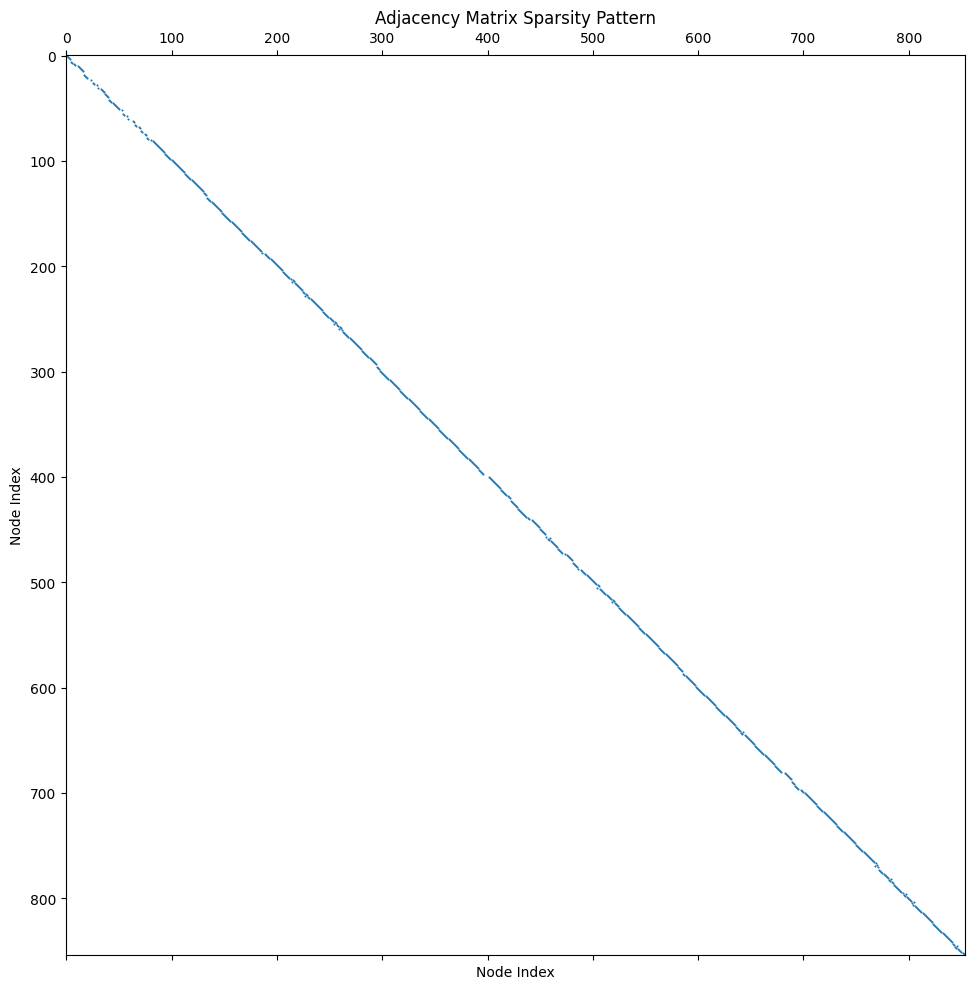

In [42]:
# 可视化邻接矩阵（稀疏模式）
fig, ax = plt.subplots(figsize=(10, 10))
ax.spy(adj_matrix, markersize=0.5)
ax.set_title('Adjacency Matrix Sparsity Pattern')
ax.set_xlabel('Node Index')
ax.set_ylabel('Node Index')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'adjacency_matrix_spy.png'), dpi=150)
plt.show()

## 11. 保存图数据

In [43]:
# 保存节点列表
node_data = []
for i, node_id in enumerate(node_order):
    d = G.nodes[node_id]
    node_data.append({
        'Index': i,
        'ID': node_id,
        'Fwy': d['fwy'],
        'Dir': d['dir'],
        'Abs_PM': d['abs_pm'],
        'Latitude': d['lat'],
        'Longitude': d['lon'],
        'Lanes': d['lanes'],
        'Name': d['name']
    })

node_df = pd.DataFrame(node_data)
node_df.to_csv(os.path.join(OUTPUT_DIR, 'graph_nodes.csv'), index=False)
print(f"节点列表已保存: graph_nodes.csv")

节点列表已保存: graph_nodes.csv


In [44]:
# 保存边列表
edge_data = []
node_to_idx = {node_id: i for i, node_id in enumerate(node_order)}

for u, v, d in G.edges(data=True):
    edge_data.append({
        'Source': u,
        'Target': v,
        'Source_Idx': node_to_idx[u],
        'Target_Idx': node_to_idx[v],
        'Distance': d['distance'],
        'Weight': d['weight'],
        'Fwy': d['fwy'],
        'Dir': d['dir']
    })

edge_df = pd.DataFrame(edge_data)
edge_df.to_csv(os.path.join(OUTPUT_DIR, 'graph_edges.csv'), index=False)
print(f"边列表已保存: graph_edges.csv")

边列表已保存: graph_edges.csv


In [45]:
# 保存邻接矩阵（numpy 格式）
np.save(os.path.join(OUTPUT_DIR, 'adjacency_matrix.npy'), adj_matrix)
print(f"邻接矩阵已保存: adjacency_matrix.npy")

# 保存节点顺序
np.save(os.path.join(OUTPUT_DIR, 'node_order.npy'), np.array(node_order))
print(f"节点顺序已保存: node_order.npy")

邻接矩阵已保存: adjacency_matrix.npy
节点顺序已保存: node_order.npy


In [46]:
# 保存为 GraphML 格式（可用 Gephi 等工具打开）
nx.write_graphml(G, os.path.join(OUTPUT_DIR, 'traffic_graph.graphml'))
print(f"GraphML 已保存: traffic_graph.graphml")

GraphML 已保存: traffic_graph.graphml


---
## 输出文件说明

| 文件 | 说明 |
|------|------|
| `graph_nodes.csv` | 节点列表（含索引、ID、属性） |
| `graph_edges.csv` | 边列表（含源、目标、距离、权重） |
| `adjacency_matrix.npy` | 邻接矩阵（numpy格式） |
| `node_order.npy` | 节点顺序（与邻接矩阵对应） |
| `traffic_graph.graphml` | GraphML格式（可视化工具用） |
| `traffic_graph_map_full.html` | 完整交通图地图 |
| `traffic_graph_map_80.html` | I-80 地图 |
| `traffic_graph_map_50.html` | US-50 地图 |

### 地图使用说明

1. **点击节点**：查看详细信息（ID, Fwy, Dir, Abs_PM, Lanes, Name）
2. **悬停边上**：查看边信息（源→目标, 距离）
3. **三角形箭头**：表示边的方向
4. **颜色**：不同高速公路用不同颜色区分